# Online Retail Analysis

### Proyecto Final de Codecademy Data Scientist: Analytics

## Autor: Agustín Pluda

# Índice de Contenidos
- [Descripción](#descripción)
- [Objetivo](#objetivo)
- [1. Importación de Librerias](#1-importacion-de-librerias)
- [2. Carga del dataset](#2-carga-del-dataset)
- [3. Exploración Inicial](#3-exploración-inicial)
  - [3.1 Limpieza de Datos](#31-limpieza-de-datos)
  - [3.2 Formateo de Datos](#32-formateo-de-datos)
  - [3.3 Creación de Dataframes para el análisis](#33-creación-de-dataframes-para-el-análisis)
  - [3.4 Guardado de Dataframes a CSV](#34-guardado-de-dataframes-a-csv)
- [4. Análisis Exploratorio de Datos (EDA)](#4-analisis-exploratorio-de-datos-eda)
  - [4.1 Articulos](#41-articulos)
  - [4.2 Facturas y Clientes](#42-facturas-y-clientes)
  - [4.3 Fechas y Horas](#43-fechas-y-horas)
  - [4.4 Paises](#44-paises)
  - [4.5 Extras](#45-extras)
- [5. Hallazgos Claves](#5-hallazgos-claves)
- [6. Conclusiones](#6-conclusiones)

## Descripción
Este proyecto se trata del final de mi curso de "Data Scientist: Analytics" de Codecademy, en el cual, a través de un análisis de datos de un dataset a elección propia, demostrando gran parte de lo que he aprendido en mi tiempo de cursado.

El dataset que elegí fue "online_retail_II.csv" (https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci), que se trata de todas las transacciones realizadas por una empresa de venta minorista en línea, registrada en el Reino Unido y sin establecimiento físico, entre el 1 de diciembre de 2009 y el 9 de diciembre de 2011. La empresa se dedica principalmente a la venta de artículos de regalo únicos para cualquier ocasión. Muchos de sus clientes son mayoristas.

Elegí este dataset porque contiene más de un millón de filas de datos, en las cuales hay datos faltantes, inconsistentes y formatos incorrectos, etc.

## Objetivo
El objetivo este proyecto es el proceso completo de análisis del dataset, que se trata de:
- Carga del dataset, 
- Exploración Inicial de los datos, 
- Curado de los datos (limpieza y formateo), 
- Análisis exploratorio de datos (EDA) con preguntas de negocio, 
- Hallazgos claves, 
- Conclusión.

# 1. Importación de Librerias

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

plt.style.use("default")
%matplotlib inline

# 2. Carga del dataset

Primero cargamos el dataset y inspeccionamos su estructura.

In [2]:
df = pd.read_csv("../online-retail-analysis/data/online_retail_II.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# 3. Exploración Inicial
Vamos a entender la estructura de los datos antes de realizar cualquier análisis.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [4]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [5]:
df.shape

(1067371, 8)

## 3.1 Limpieza de Datos

### 3.1.1 Datos Nulos

In [6]:
print(df.isnull().sum())
print("")
print("Valores Nulos Totales:", df.isnull().sum().sum())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Valores Nulos Totales: 247389


Tenemos 247.389 celdas vacías de datos, los cuales 
- 243.007 corresponden a IDs de clientes y 
- 4.382 corresponden a descripción de producto.

En este caso, me procederé a borrar las filas de datos que no tengan descripción, si lo dejo puede ser problemático para realizar los gráficos y análisis posteriores. En el caso de los IDs de cliente, no tendré problema de dejarlos, al fin al cabo mi análisis no estará enfocados en ellos.


In [7]:
df.dropna(subset=["Description"], inplace=True)

print("Valores nulos después de la limpieza:")
print(df.isnull().sum())

Valores nulos después de la limpieza:
Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    238625
Country             0
dtype: int64


### 3.1.2 Datos Duplicados

In [8]:
print("Filas Duplicadas:", df.duplicated().sum())

Filas Duplicadas: 34228


Este dataset contiene 34.335 filas duplicadas, en este caso las vamos a extraer porque afectaría nuestro posterior análisis, dando visualizaciones erróneas de lo que realmente contiene el set.

In [9]:
df.drop_duplicates(inplace=True)

print("Filas duplicadas después de la limpieza:", df.duplicated().sum())

Filas duplicadas después de la limpieza: 0


### 3.1.3 Registros no comerciales
El atributo StockCode identifica cada producto del dataset. La mayoría de los códigos siguen el formato de cinco dígitos, aunque también existen productos con variantes identificadas mediante letras, por ejemplo 85049A y 85049B. Por este motivo, no se consideraron inválidos los códigos únicamente por contener letras.

Para identificar registros que no correspondieran al formato habitual de los productos, se utilizó una expresión regular que detecta códigos formados por cinco dígitos, opcionalmente seguidos de letras:


In [10]:
# Identificar StockCode que no siguen el formato habitual de productos
special_codes = df[~df["StockCode"].str.match(r"^\d{5}[A-Za-z]*$", na=False)]

print(special_codes["StockCode"].value_counts())

StockCode
POST            2079
DOT             1423
M               1387
C2               274
D                173
S                101
BANK CHARGES     100
ADJUST            67
AMAZONFEE         36
DCGS0058          30
gift_0001_20      27
gift_0001_30      24
DCGSSGIRL         24
DCGSSBOY          22
PADS              19
CRUK              16
TEST001           15
DCGS0076          14
DCGS0003          14
gift_0001_10      14
gift_0001_50       6
DCGS0069           6
B                  6
m                  5
gift_0001_40       5
DCGS0004           4
DCGS0068           3
DCGS0072           3
ADJUST2            3
gift_0001_80       2
DCGS0066N          2
DCGS0070           2
SP1002             2
DCGS0044           1
TEST002            1
DCGS0075           1
DCGS0041           1
gift_0001_70       1
DCGS0037           1
47503J             1
DCGS0062           1
DCGS0073           1
DCGS0067           1
Name: count, dtype: int64


A partir de esta revisión, se identificaron dos grupos:

**Códigos que representan productos o servicios comerciales y se conservarán:**

- DCGS...: corresponden a productos reales, como DCGS0003 (BOXED GLASS ASHTRAY) y DCGSSGIRL (GIRLS PARTY BAG).
- gift_0001_XX: corresponden a gift vouchers de distintos valores.
- SP1002: corresponde al producto KID'S CHALKBOARD/EASEL.

Estos códigos **no se eliminarán**, ya que representan artículos o servicios comercializados.

**Códigos que corresponden a registros administrativos, cargos o registros no relacionados con la venta de productos y serán excluidos del análisis de artículos:**

- ADJUST y ADJUST2: ajustes administrativos.
- AMAZONFEE: cargos de Amazon.
- BANK CHARGES: cargos bancarios.
- B: ajustes de deuda.
- C2, D y S: registros especiales.
- CRUK: registro especial.
- M y m: registros manuales.
- PADS: registro especial.
- POST: gastos de envío (POSTAGE).
- DOT: gastos de envío de Dotcom (DOTCOM POSTAGE).
- TEST001 y TEST002: registros de prueba.

Para evitar eliminar esta información del DataFrame original, se creó un nuevo DataFrame destinado específicamente al análisis de productos:

In [11]:
# Códigos correspondientes a registros no comerciales 
non_product_codes = [ "ADJUST", "ADJUST2", "AMAZONFEE", "BANK CHARGES", "B", "C2", "CRUK", 
                     "D", "M", "m", "PADS", "POST", "S", "TEST001", "TEST002", "DOT" ] 

# DataFrame destinado al análisis de productos 
df_products = df[~df["StockCode"].isin(non_product_codes)].copy()

print("Registros originales:", len(df))
print("Registros para análisis de productos:", len(df_products))
print("Registros excluidos:", len(df) - len(df_products))

Registros originales: 1028761
Registros para análisis de productos: 1023056
Registros excluidos: 5705


De esta manera, el DataFrame original conserva todos los registros del dataset, mientras que df_products permite realizar análisis centrados exclusivamente en artículos y servicios comercializados, evitando que cargos, ajustes, gastos de envío y registros administrativos distorsionen los resultados.

### 3.1.4 Valores inconsistentes en Quantity y Price

In [12]:
# Cantidades menores o iguales a cero
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())

# Precios menores o iguales a cero
print("Price <= 0:", (df["Price"] <= 0).sum())

Quantity <= 0: 19863
Price <= 0: 1744


In [13]:
# Identificar facturas canceladas
canceled = df["Invoice"].str.upper().str.startswith("C")

print("Quantity <= 0 en facturas canceladas:",
      ((df["Quantity"] <= 0) & canceled).sum())

print("Quantity <= 0 en facturas no canceladas:",
      ((df["Quantity"] <= 0) & ~canceled).sum())

Quantity <= 0 en facturas canceladas: 19103
Quantity <= 0 en facturas no canceladas: 760


In [14]:
df[(df["Quantity"] <= 0) & ~canceled][["Invoice", "StockCode", "Description", "Quantity", "Price"]].head(20)

,Invoice,StockCode,Description,Quantity,Price
263,489464,21733,85123a mixed,-96,0.0
283,489463,71477,short,-240,0.0
284,489467,85123A,21733 mixed,-192,0.0
3162,489660,35956,lost,-1043,0.0
3168,489663,35605A,damages,-117,0.0
4538,489820,21133,invcd as 84879?,-720,0.0
6556,489899,79323GR,sold as gold,-954,0.0
6911,490007,84347,21494,-720,0.0
9308,490130,21493,lost?,-600,0.0
17427,490765,21450,damaged,-31,0.0


In [15]:
df[df["Price"] <= 0][["Invoice", "StockCode", "Description", "Quantity", "Price"]].head(20)

,Invoice,StockCode,Description,Quantity,Price
263,489464,21733,85123a mixed,-96,0.0
283,489463,71477,short,-240,0.0
284,489467,85123A,21733 mixed,-192,0.0
3162,489660,35956,lost,-1043,0.0
3168,489663,35605A,damages,-117,0.0
4538,489820,21133,invcd as 84879?,-720,0.0
4674,489825,22076,6 RIBBONS EMPIRE,12,0.0
5904,489861,DOT,DOTCOM POSTAGE,1,0.0
6556,489899,79323GR,sold as gold,-954,0.0
6781,489998,48185,DOOR MAT FAIRY CAKE,2,0.0


Se analizaron los valores no positivos de las variables Quantity y Price, ya que ambos atributos son fundamentales para calcular el valor de las transacciones y realizar posteriormente el análisis de ventas.

En primer lugar, se identificaron 19.863 registros con Quantity <= 0. Al comparar estos registros con las facturas canceladas, se observó que 19.103 corresponden a facturas cuyo Invoice comienza con C, mientras que 760 registros presentan cantidades no positivas sin estar asociados a una factura cancelada.

Los registros que no corresponden a facturas canceladas contienen descripciones como "lost", "damaged", "wet", "bad quality", "missing", "smashed" y "discoloured", lo que indica que corresponden principalmente a ajustes o incidencias relacionadas con el inventario y no a ventas normales.

También se identificaron 1.744 registros con Price <= 0. Dentro de estos registros existen tanto cantidades negativas como transacciones con cantidades positivas y precio igual a cero. Debido a que un precio no positivo no representa una venta con valor monetario para el análisis de ingresos, estos registros no serán utilizados en el análisis de ventas.

Por lo tanto, se conservará el DataFrame original para mantener la información completa del dataset, mientras que para el análisis de ventas se creará un nuevo DataFrame que contenga únicamente transacciones con cantidades y precios positivos:

In [16]:
# DataFrame para el análisis de ventas 
df_sales = df_products[(df_products["Quantity"] > 0) & (df_products["Price"] > 0)].copy()

print("Registros en df_products:", len(df_products)) 
print("Registros en df_sales:", len(df_sales)) 
print("Registros excluidos:", len(df_products) - len(df_sales))

Registros en df_products: 1023056
Registros en df_sales: 1003417
Registros excluidos: 19639


De esta manera, los registros de cancelaciones, devoluciones, ajustes de inventario y transacciones sin valor monetario no se eliminan del dataset original, pero tampoco interfieren en los análisis posteriores relacionados con cantidades vendidas, precios, ingresos y productos más vendidos.

## 3.2 Formateo de Datos

### 3.2.1 Renombramiento de columnas

Para facilitar el trabajo con las variables durante el análisis, se renombraron todas las columnas utilizando el formato snake_case.

Además, la columna InvoiceDate fue renombrada como invoice_datetime, ya que a que contiene tanto la fecha como la hora en la que se generó cada transacción, por lo que el nombre original no representa completamente su contenido.

In [17]:
df.rename(columns={"Invoice": "invoice", 
                   "StockCode": "stock_code", 
                   "Description": "description", 
                   "Quantity": "quantity", 
                   "InvoiceDate": "invoice_datetime", 
                   "Price": "unit_price", 
                   "Customer ID": "customer_id", 
                   "Country": "country"
                   }, inplace=True)

### 3.2.2 Corrección de tipos de datos

Se revisaron los tipos de datos de las columnas para asegurar que cada variable tenga un formato adecuado para las operaciones que se realizarán posteriormente.

La columna customer_id fue convertida a tipo string, debido a que representa un identificador de cliente y no una variable numérica sobre la cual se realizarán operaciones matemáticas.

Por otro lado, invoice_datetime fue convertida al formato datetime, permitiendo realizar operaciones relacionadas con fechas y horas, como extraer años, meses, días y horas.

In [18]:
df = df.astype({"customer_id":"string"})
df["invoice_datetime"] = pd.to_datetime(df["invoice_datetime"])

### 3.2.3 Agregado de columnas

Finalmente, se agregaron nuevas variables derivadas de las columnas existentes con el objetivo de facilitar el análisis exploratorio posterior.

En primer lugar, se separaron la fecha y la hora de la transacción a partir de invoice_datetime. Esto permitirá analizar el comportamiento de las ventas según diferentes períodos de tiempo.

También se creó la variable booleana canceled, que indica si una factura corresponde a una cancelación. Según la estructura del dataset, las facturas cuyo código comienza con "C" corresponden a cancelaciones.

Por último, se creó total_price, calculada como el producto entre la cantidad de unidades y el precio unitario. Esta variable representa el valor total de cada línea de transacción.

In [19]:
# Fecha y hora de la factura por separado
df["invoice_date"] = df["invoice_datetime"].dt.normalize()
df["invoice_time"] = df["invoice_datetime"].dt.time

# Identificar facturas canceladas
df["canceled"] = df["invoice"].str.startswith("C")

# Precio total de cada línea de transacción
df["total_price"] = df["quantity"] * df["unit_price"]

## 3.3 Creación de Dataframes para el análisis
Una vez finalizadas las etapas de limpieza y formateo, se crearon DataFrames específicos para los distintos análisis que se realizarán durante el EDA.

El objetivo es conservar df como el DataFrame principal, manteniendo la información disponible después del proceso de limpieza, y generar subconjuntos destinados a análisis específicos.

### 3.3.1 DataFrame de productos

Se creó df_products, que contiene únicamente los registros correspondientes a productos o servicios comercializados. Para ello, se excluyeron los códigos identificados previamente como registros administrativos, cargos, ajustes, gastos de envío o registros de prueba.

In [20]:
# Códigos correspondientes a registros no comerciales 
non_product_codes = [ "ADJUST", "ADJUST2", "AMAZONFEE", "BANK CHARGES", "B", "C2", "CRUK", 
                     "D", "M", "m", "PADS", "POST", "S", "TEST001", "TEST002", "DOT" ] 

# DataFrame destinado al análisis de productos 
df_products = df[~df["stock_code"].isin(non_product_codes)].copy()

print("Registros originales:", len(df))
print("Registros para análisis de productos:", len(df_products))
print("Registros excluidos:", len(df) - len(df_products))

Registros originales: 1028761
Registros para análisis de productos: 1023056
Registros excluidos: 5705


De esta manera, df_products permite realizar análisis relacionados con los artículos comercializados sin que cargos administrativos, gastos de envío o registros especiales alteren los resultados.

### 3.3.2 DataFrame de ventas

A partir de df_products se creó df_sales, destinado específicamente al análisis de las ventas efectivas.

Se conservaron únicamente las transacciones que presentan una cantidad y un precio unitario positivos. De esta forma, se excluyen cancelaciones, devoluciones, ajustes de inventario y registros sin valor monetario.

In [21]:
# DataFrame destinado al análisis de ventas
df_sales = df_products[(df_products["quantity"] > 0) & (df_products["unit_price"] > 0)].copy()

print("Registros en df_products:", len(df_products)) 
print("Registros en df_sales:", len(df_sales))
print("Registros excluidos:", len(df_products) - len(df_sales))

Registros en df_products:

 1023056
Registros en df_sales: 1003417
Registros excluidos: 19639


df_sales será el DataFrame principal para los análisis relacionados con cantidades vendidas, precios, ingresos y productos más comprados.

## 3.4 Guardado de Dataframes a CSV
Se guardaron tres versiones del dataset:

- online_retail_clean.csv: contiene el dataset después de las etapas generales de limpieza y formateo.
- online_retail_products.csv: contiene únicamente los registros correspondientes a productos o servicios comercializados.
- online_retail_sales.csv: contiene únicamente las transacciones consideradas ventas efectivas, con cantidades y precios positivos.

In [22]:
#df.to_csv("data/online_retail_clean.csv", index=False) 
#df_products.to_csv("data/online_retail_products.csv", index=False) 
#df_sales.to_csv("data/online_retail_sales.csv", index=False)

# 4. Análisis Exploratorio de Datos (EDA)

Ahora vamos con lo divertido.

## 4.1 Articulos

### 4.1.1 ¿Cuales son los 10 articulos más comprados?
Empezando con algo simple, querria ver que es lo que más compran los clientes como regalos.

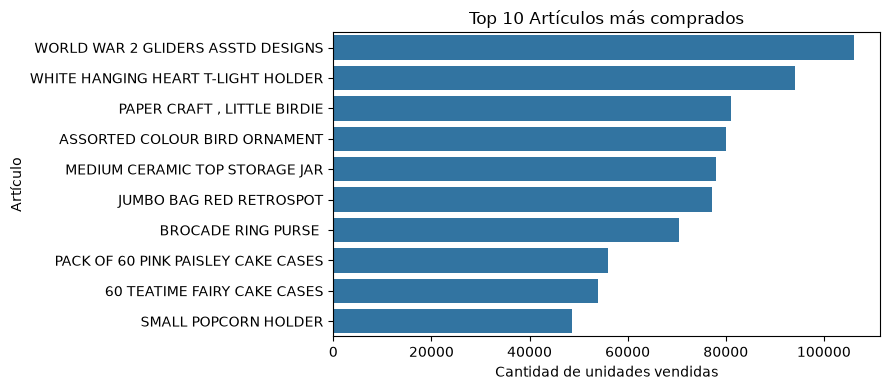

In [23]:
articulos = (df_sales.groupby(["stock_code", "description"])["quantity"].sum().reset_index().sort_values("quantity", ascending=False))
arti_top = articulos.head(10)
arti_top = arti_top.sort_values("quantity", ascending=False)

plt.figure(figsize=(9, 4))

sns.barplot(data=arti_top, x="quantity", y="description", color="tab:blue")

plt.xlabel("Cantidad de unidades vendidas")
plt.ylabel("Artículo")
plt.title("Top 10 Artículos más comprados")

plt.tight_layout()
#plt.savefig("images/top_10_articulos_comprados.png", dpi=300, bbox_inches="tight")
plt.show()

**Observación:** Con más de 100.000 unidades vendidas, el top 1 se tratan de aviones de la segunda guerra mundial armables de cartón. Siguiendo el grafico, el top 2 se trata de porta velas colgante blanco con forma de corazón. Y con el top 3 para finalizar se trata de un pack de armado de manualidades de papel de Little Birdie. Como podemos ver, lo que más se compra se trata de regalos para niños los cuales son realmente baratos y para esos tiempos (2009 a 2011) podías entretener a un niño/a con ellos.

### 4.1.2 ¿Cuáles son los 10 artículos más caros por unidad?
Vamos a revisar que es lo más caro que se podía comprar en vía online en eso tiempos.

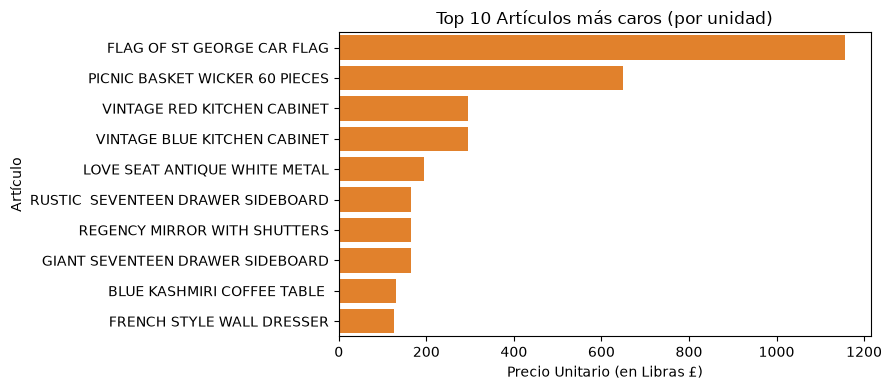

In [24]:
top_10_caros = (df_sales.groupby(["stock_code", "description"], as_index=False)["unit_price"]
                    .max().sort_values("unit_price", ascending=False).head(10))

plt.figure(figsize=(9, 4))

sns.barplot(data=top_10_caros, x="unit_price", y="description", color="tab:orange")

plt.xlabel("Precio Unitario (en Libras £)")
plt.ylabel("Artículo")
plt.title("Top 10 Artículos más caros (por unidad)")

plt.tight_layout()
# plt.savefig("images/top_10_articulos_caros.png", dpi=300, bbox_inches="tight")
plt.show()

**Observación:** Dentro del top 10, los que más resaltan son el primero y segundo puesto. El primero, es una bandera de coche de Inglaterra, que fue comprada por casi 1200 libras, me parece bastante dinero para invertir en una pequeña bandera con mástil de plástico. Y en el segundo puesto, Tenemos la compra de 60x canastos de picnic hechos de mimbre al precio de poco más de 600 libras, que en este caso me parece más razonable el costo comparado a lo anterior.

Por lo demás artículos del top, podemos encontrarnos en su mayoría con muebles, que dependiendo el tamaño y la calidad de estos tiene sentido su costo de compra.

### 4.1.3 ¿Y cuáles son los 10 artículos más baratos por unidad?
Ya revisamos los más caros, ahora vamos por los más baratos y tal vez nos encontramos algo interesante.

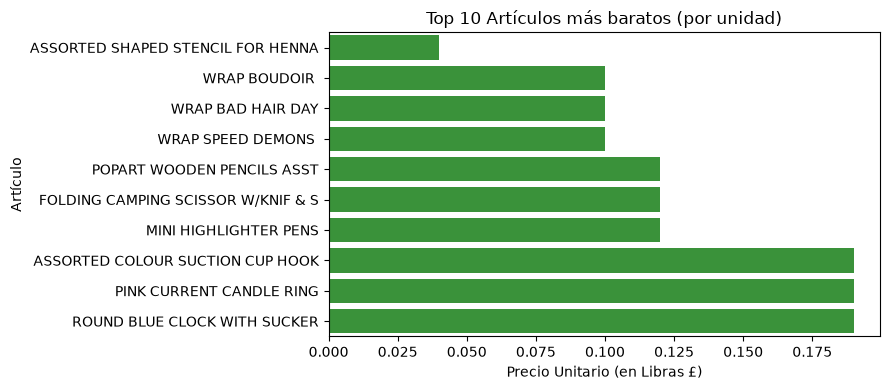

In [25]:
top_10_baratos = (df_sales.groupby(["stock_code", "description"], as_index=False)["unit_price"]
                    .max().sort_values("unit_price", ascending=True).head(10))

plt.figure(figsize=(9, 4))

sns.barplot(data=top_10_baratos, x="unit_price", y="description", color="tab:green")

plt.xlabel("Precio Unitario (en Libras £)")
plt.ylabel("Artículo")
plt.title("Top 10 Artículos más baratos (por unidad)")

plt.tight_layout()
# plt.savefig("images/top_10_articulos_baratos.png", dpi=300, bbox_inches="tight")
plt.show()

**Observación:** En el primer puesto y con un costo unitario de solo 0.03 libras, tenemos plantilla de formas variadas que básicamente se utilizan en la piel, luego entre top de los que cuestan 0.1 libras, son envolturas de distintos tipos, y por lo demás tenemos unos cuantos artículos variados, que lo destacable que comparten, es que se tratan de objetos pequeños.

### 4.1.4 Y hablando de costos y cantidades, ¿Es más probable que compren más cantidad si es más barato el producto en unidad?
Por un tema económico, parece ser obvio que sí, pero quiero ver que tan fuerte es esta relación entre lo barato y la cantidad a través de un gráfico de correlación.

In [26]:
"""
# Correlación
correlation = df_sales["unit_price"].corr(df_sales["quantity"])

# Límites para visualizar el 95% central
x_min = df_sales["unit_price"].quantile(0.025)
x_max = df_sales["unit_price"].quantile(0.975)

y_min = df_sales["quantity"].quantile(0.025)
y_max = df_sales["quantity"].quantile(0.975)

plt.figure(figsize=(8, 7))

sns.regplot(data=df_sales, x="unit_price", y="quantity", 
            scatter_kws={"color":"tab:blue", "alpha": 0.2}, 
            line_kws={"color":"black", "linewidth": 2})

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.text(0.03, 0.97, f"r = {correlation:.3f}", transform=plt.gca().transAxes, fontsize=11, 
         verticalalignment="center", bbox=dict(facecolor="white", alpha=1, edgecolor="black"))

plt.xlabel("Precio Unitario (en Libras £)")
plt.ylabel("Cantidad de unidades")
plt.title("Relación entre Precio Unitario y Cantidad")

plt.tight_layout()
plt.savefig("images/relacion_precio_cantidad.png", dpi=300, bbox_inches="tight")
plt.show()
"""


'\n# Correlación\ncorrelation = df_sales["unit_price"].corr(df_sales["quantity"])\n\n# Límites para visualizar el 95% central\nx_min = df_sales["unit_price"].quantile(0.025)\nx_max = df_sales["unit_price"].quantile(0.975)\n\ny_min = df_sales["quantity"].quantile(0.025)\ny_max = df_sales["quantity"].quantile(0.975)\n\nplt.figure(figsize=(8, 7))\n\nsns.regplot(data=df_sales, x="unit_price", y="quantity", \n            scatter_kws={"color":"tab:blue", "alpha": 0.2}, \n            line_kws={"color":"black", "linewidth": 2})\n\nplt.xlim(x_min, x_max)\nplt.ylim(y_min, y_max)\n\nplt.text(0.03, 0.97, f"r = {correlation:.3f}", transform=plt.gca().transAxes, fontsize=11, \n         verticalalignment="center", bbox=dict(facecolor="white", alpha=1, edgecolor="black"))\n\nplt.xlabel("Precio Unitario (en Libras £)")\nplt.ylabel("Cantidad de unidades")\nplt.title("Relación entre Precio Unitario y Cantidad")\n\nplt.tight_layout()\nplt.savefig("images/relacion_precio_cantidad.png", dpi=300, bbox_inches

**Observación:** Al final no era tan obvio, la correlación que existe entre el precio unitario y la cantidad de unidades compradas es de tan solo -0.029, lo cual es prácticamente nula.

Lo único que no me sorprende es que la relación sea negativa, acá es donde se respeta la teoría económica general, en donde la disposición de una persona por comprar un producto (demanda), vaya disminuyendo por la subida del precio del producto (oferta).

## 4.2 Facturas y Clientes

### 4.2.1 ¿Cuánto gasta el cliente en promedio por factura?
Enfocándonos más en las facturas del dataset, cual sería el gasto promedio por cada compra que realiza.

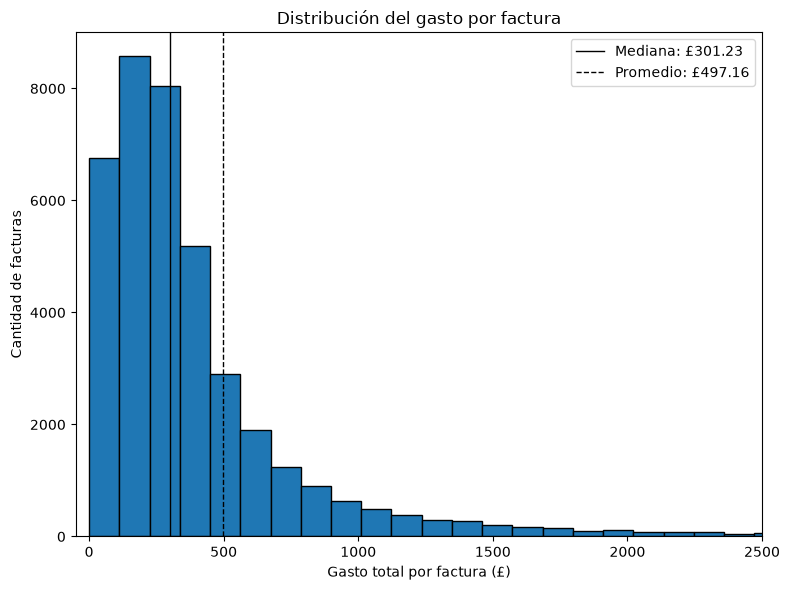

In [27]:
factura_precio_total = (df_sales.groupby("invoice")["total_price"].sum())

factura_promedio = factura_precio_total.mean()
factura_mediana = factura_precio_total.median()

#print(f"Gasto promedio por factura: £{factura_promedio:.2f}")

plt.figure(figsize=(8, 6))

plt.hist(factura_precio_total, bins=1500, color="tab:blue", edgecolor="black")

plt.axvline(factura_mediana, linewidth=1, color="black" ,label=f"Mediana: £{factura_mediana:.2f}")
plt.axvline(factura_promedio, linestyle="--", linewidth=1, color="black" ,label=f"Promedio: £{factura_promedio:.2f}")

plt.xlim(-50, 2500)

plt.xlabel("Gasto total por factura (£)")
plt.ylabel("Cantidad de facturas")
plt.title("Distribución del gasto por factura")
plt.legend()

plt.tight_layout()
# plt.savefig("images/gasto_promedio_factura.png", dpi=300, bbox_inches="tight")
plt.show()

**Observación:** El gasto promedio por factura es de £497.16, que si lo pensáramos como si los compradores solo fueran clientes minoristas parecería mucho dinero, pero desde la descripción del dataset, se narra que hay una gran parte de compradores mayoristas los cuales ponen un peso en la balanza del gasto promedio.

Por otro lado, también decidí mostrar la mediana, la cual es de £301.23, notablemente menor comparado a los casi £500 del promedio, y en este dato es donde los clientes minoristas tienen un poco más de protagonismo, porque la mediana toma la posición central (50%) de los datos, haciendo que se tome más en cuenta la población de facturas de minoristas en los datos.

#### Grafico Adicional: Boxplot Gasto por Factura

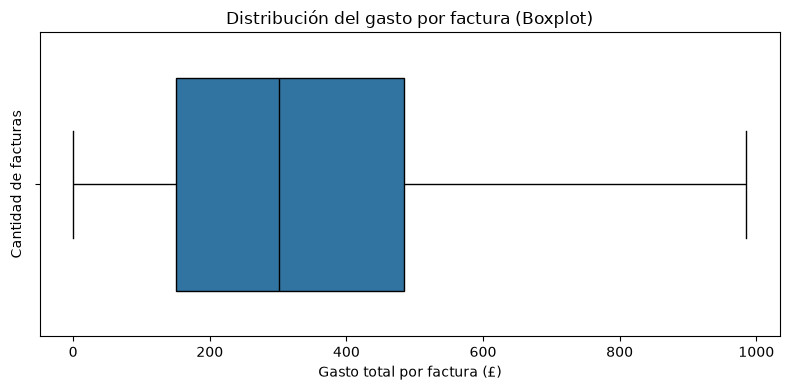

In [28]:
plt.figure(figsize=(8, 4))

sns.boxplot(data=factura_precio_total, orient="h", color="tab:blue", linecolor="black", width=0.7, showfliers=False)

#plt.xlim(-15, 1000)

plt.xlabel("Gasto total por factura (£)")
plt.ylabel("Cantidad de facturas")
plt.title("Distribución del gasto por factura (Boxplot)")

plt.tight_layout()
# plt.savefig("images/gasto_promedio_factura_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.2.2 ¿Cuáles son las facturas más caras?
Ya vimos promedio y mediana, ahora vamos con algo más extremo.

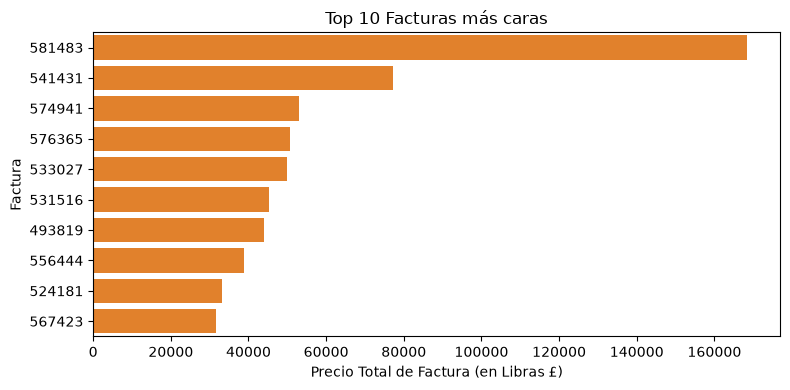

In [29]:
facturas_caras = (df_sales.groupby(["invoice"], as_index=False)["total_price"]
                    .sum().sort_values("total_price", ascending=False).head(10))

plt.figure(figsize=(8, 4))

sns.barplot(data=facturas_caras, x="total_price", y="invoice", color="tab:orange")

plt.xlabel("Precio Total de Factura (en Libras £)")
plt.ylabel("Factura")
plt.title("Top 10 Facturas más caras")

plt.tight_layout()
# plt.savefig("images/top_10_facturas_caras.png", dpi=300, bbox_inches="tight")
plt.show()

**Observación:** Como podemos ver, hay una factura que resalta sobre las demás, que es la N° 581.483, la cual gasto más de £160.000 en realizar esta compra online.

Mi duda ya no es que tanto gasto, sino en que...

In [30]:
top1 = df_sales[df_sales["invoice"] == "581483"]
print(top1[["description", "quantity", "unit_price", "total_price", "customer_id"]])

                         description  quantity  unit_price  total_price  \
1065882  PAPER CRAFT , LITTLE BIRDIE     80995        2.08     168469.6   

        customer_id  
1065882     16446.0  


¡Que interesante! Solo compro un tipo de artículo, paquetes de armado de papel de Little Birdie, por una cantidad de casi 81.000 unidades (!!) que le termino costando lo que vemos en la factura. Acabamos de identificar al principal culpable de que este articulo sea el top 3 más comprados (figura 4.1.1) del dataset. 

### 4.2.3 ¿Que clientes gastaron más?
Si bien no podemos identificar a los clientes (solo tenemos sus códigos ID), podemos saber quién gasto más en el periodo que contienen los datos.

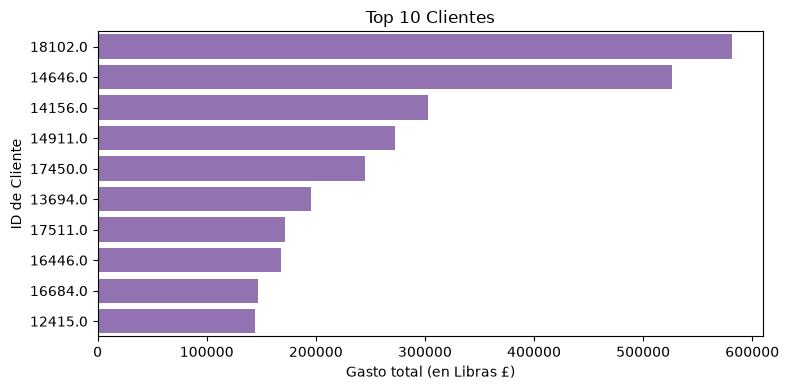

In [31]:
top_clientes = (df_sales.groupby(["customer_id"], as_index=False)["total_price"]
                    .sum().sort_values("total_price", ascending=False).head(10))

plt.figure(figsize=(8, 4))

sns.barplot(data=top_clientes, x="total_price", y="customer_id", color="tab:purple")

plt.xlabel("Gasto total (en Libras £)")
plt.ylabel("ID de Cliente")
plt.title("Top 10 Clientes")

plt.tight_layout()
# plt.savefig("images/top_10_clientes.png", dpi=300, bbox_inches="tight")
plt.show()

**Observación:** Un detalle a destacar es que el top 8 (ID N° 16446) es el mismo cliente que tiene la factura más cara del dataset.

## 4.3 Fechas y Horas

### 4.3.1 ¿Existe un aumento de la cantidad de compras por año?
En este caso vamos a tener en cuenta solo los años 2010 y 2011, ya que, en este dataset, el 2009 solo contiene las transacciones del mes de diciembre, por lo cual haría la comparación dispareja respecto a los otros 2 años.

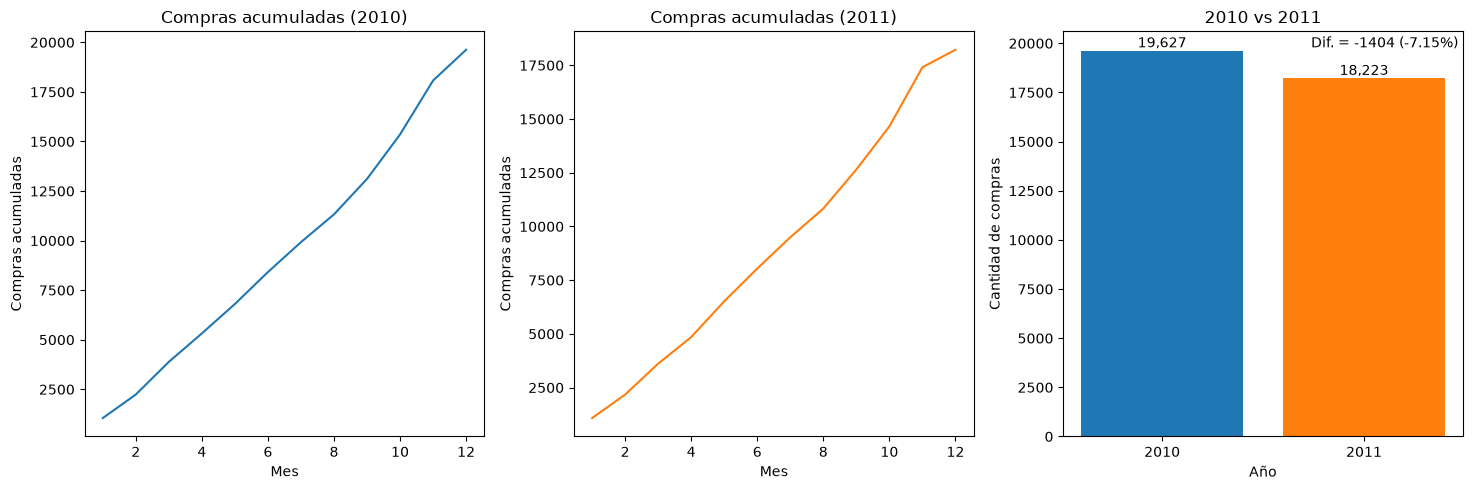

In [32]:
df_sales["year"] = df_sales["invoice_datetime"].dt.year
df_sales["month"] = df_sales["invoice_datetime"].dt.month

compras_por_mes = (df_sales[df_sales["year"].isin([2010, 2011])].groupby(["year", "month"])
                      ["invoice"].nunique().reset_index())

compras_por_mes["acumulado"] = (compras_por_mes.groupby("year")["invoice"].cumsum())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfico 2010
data_2010 = compras_por_mes[compras_por_mes["year"] == 2010]

axes[0].plot(data_2010["month"], data_2010["acumulado"])

axes[0].set_title("Compras acumuladas (2010)")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Compras acumuladas")

# Gráfico 2011
data_2011 = compras_por_mes[compras_por_mes["year"] == 2011]

axes[1].plot(data_2011["month"], data_2011["acumulado"], color="tab:orange")

axes[1].set_title("Compras acumuladas (2011)")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Compras acumuladas")

# Barras comparativas
values = [data_2010["acumulado"].iloc[-1], data_2011["acumulado"].iloc[-1]]
diff = values[0] - values[1]
diff_percent = 100 - (values[1] / values[0] * 100)

bar_colors = ["tab:blue", "tab:orange"]
bars = axes[2].bar(["2010", "2011"], values, color=bar_colors)

axes[2].set_xlabel("Año")
axes[2].set_ylabel("Cantidad de compras")
axes[2].set_title("2010 vs 2011")
axes[2].text(0.62, 0.97, f"Dif. = -{diff} (-{diff_percent:.2f}%)", 
             transform=plt.gca().transAxes, fontsize=10, verticalalignment="center")

for bar in bars:
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), 
                f"{int(bar.get_height()):,}",ha="center", va="bottom")

plt.tight_layout()
# plt.savefig("images/cantidad_compras_por_año", dpi=300, bbox_inches="tight")
plt.show()

**Observación:** Sorprendentemente, la cantidad de compras de un año a otro es menor, hubo una bajada del 7.15%, uno pensaría que a través de los años la tendencia de comprar vía online aumentaría, pero en este caso específico no fue así. Si el dataset tuviera más años de registros, podríamos ver si esto es así, o hay un cambio al pasar los años.

### 4.3.2 ¿En qué meses del año se compra más?
Al tratarse del mercado online de regalaría, uno ya asume en qué periodo se dan más compras de lo normal.

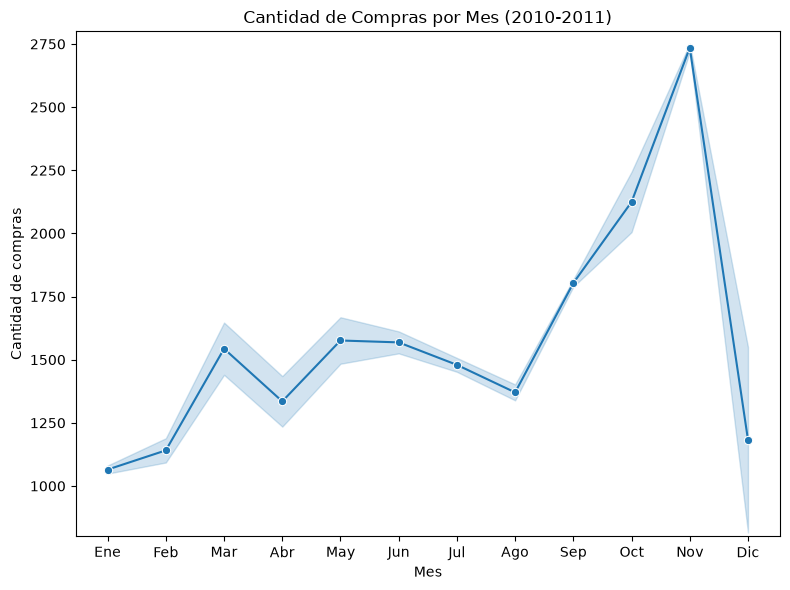

In [33]:
compras_por_mes = (df_sales[df_sales["year"].isin([2010, 2011])]
                      .groupby(["year", "month"])["invoice"].nunique().reset_index())

plt.figure(figsize=(8, 6))

sns.lineplot(data=compras_por_mes, x="month", y="invoice", marker="o")

plt.xticks(range(1, 13),["Ene", "Feb", "Mar", "Abr", "May", "Jun", 
                         "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"])
plt.ylim(800, 2800)

plt.xlabel("Mes")
plt.ylabel("Cantidad de compras")
plt.title("Cantidad de Compras por Mes (2010-2011)")

plt.tight_layout()
# plt.savefig("images/cantidad_compras_mes.png", dpi=300, bbox_inches="tight")
plt.show()

**Observación:** Como suponía, el mayor pico de compras mensuales se da en noviembre, previo a navidad y año nuevo. 

Otro pico a tener en cuenta es marzo, esto se produce porque la pascua en 2010 y 2011, se festejaron el 4 de abril y 24 de abril respectivamente, mes posterior al pico de compras de regalaría.

### 4.3.3 ¿A que hora del día se dan más compras?

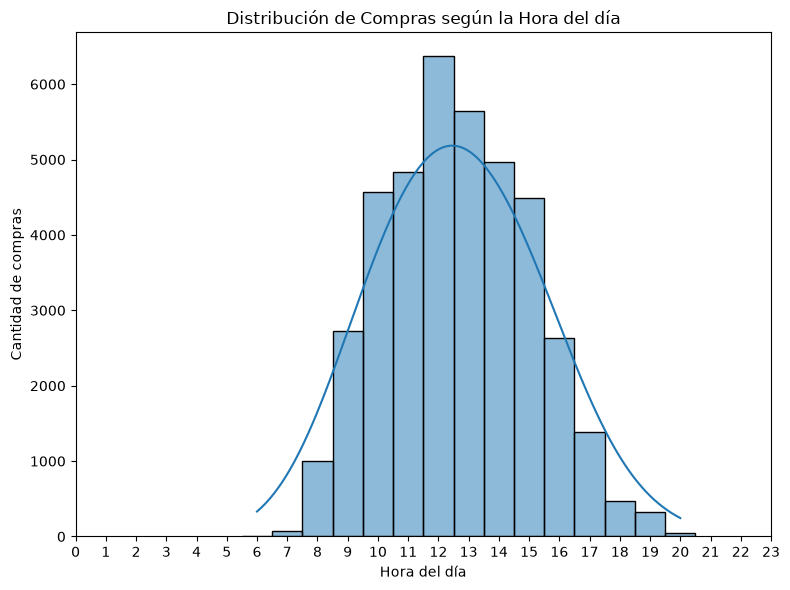

In [34]:
compras_por_hora = (df_sales.assign(hour=df_sales["invoice_datetime"].dt.hour)
                     .groupby("hour")["invoice"].nunique().reset_index())

plt.figure(figsize=(8, 6))

sns.histplot(data=compras_por_hora, x="hour", weights="invoice", bins=24, discrete=True, kde=True)

plt.xlabel("Hora del día")
plt.ylabel("Cantidad de compras")
plt.title("Distribución de Compras según la Hora del día")

plt.xticks(range(0, 24))

plt.tight_layout()
# plt.savefig("images/compras_por_hora.png", dpi=300, bbox_inches="tight")
plt.show()

**Observación:** La mayor cantidad de compras se dan alrededor del mediodía, aunque como podemos ver, las horas de la facturas están dentro de un rango horario desde las 6hs hasta las 20hs, y esto se debe que en esos años las facturas eran cargadas por personas, en su horario de empleo, el cual se encuentra distribuido como en el gráfico. Por lo tanto, las compras que eran realizadas fuera de su horario, se cargaba al día siguiente.

## 4.4 Paises

### 4.4.1 ¿De donde proviene los clientes?

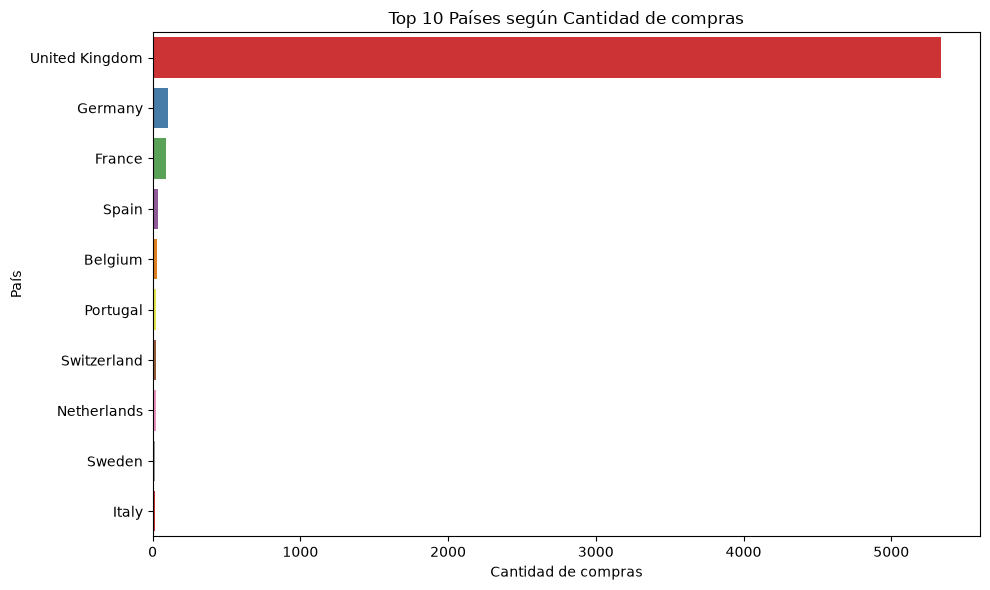

In [35]:
clientes_por_pais = (df_sales.groupby("country")["customer_id"].nunique()
                     .sort_values(ascending=False).head(10))


plt.figure(figsize=(10, 6))

sns.barplot(x=clientes_por_pais.values, y=clientes_por_pais.index, 
            palette="Set1",hue=clientes_por_pais.index, legend=False)

plt.xlabel("Cantidad de compras")
plt.ylabel("País")
plt.title("Top 10 Países según Cantidad de compras")

plt.tight_layout()
# plt.savefig("images/top_10_paises.png", dpi=300, bbox_inches="tight")
plt.show()

**Observación:** Como podemos ver, existe una enorme diferencia entre la cantidad de clientes de Reino Unido y los demás países, esto era esperable porque por el origen del dataset. Aunque, Los extranjeros, son todos europeos, la cercanía entre estos países extranjeros y el reino unido hace más posible o "fácil" el poder comprar online.

### 4.4.2 ¿Que porcentaje de clientes extranjeros hay en este dataset?

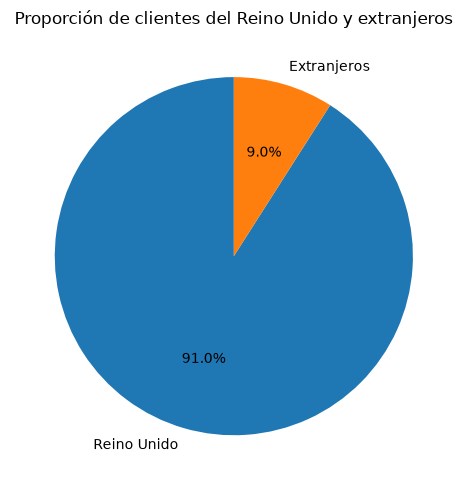

In [36]:
cliente_por_pais = (df_sales.groupby("country")["customer_id"].nunique())

cliente_uk = cliente_por_pais.get("United Kingdom", 0)
cliente_extranjero = cliente_por_pais.drop("United Kingdom").sum()

origen_cliente = pd.Series({
    "Reino Unido": cliente_uk,
    "Extranjeros": cliente_extranjero
})

plt.figure(figsize=(5, 5))

plt.pie(origen_cliente, labels=origen_cliente.index, autopct="%1.1f%%", startangle=90)

plt.title("Proporción de clientes del Reino Unido y extranjeros")

plt.tight_layout()
# plt.savefig("images/clientes_extranjeros.png", dpi=300, bbox_inches="tight")
plt.show()

**Observación:** Las ventas al extranjero solo ocupan un 9% respecto a las ventas totales, que hasta cierto punto tiene sentido, la venta de productos de regalaría online, entre el 2009 y 2011, no era normal compra al extranjero en esos tiempos esos tipos de producto. Con el paso de los años esto se termina balanceando un poco por las nuevas facilidades que existen para importar productos.

## 4.5 Extras

### 4.5.1 Matriz de Correlación

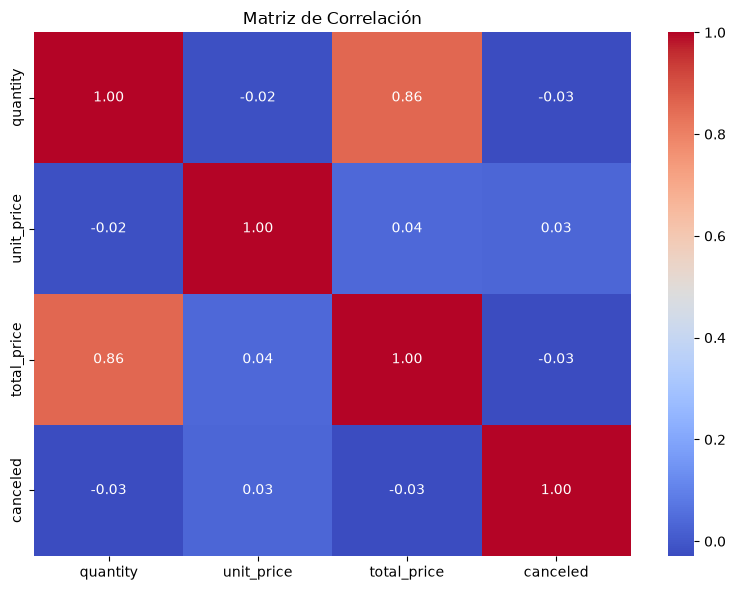

In [37]:
df_corr = df_products[["quantity", "unit_price", "total_price", "canceled"]].copy()
df_corr["canceled"] = df_corr["canceled"].astype(int)
#df_corr["stock_code"] = df_corr["stock_code"].str.extract(r"(\d+)").astype('Int64')
#df_corr["country_code"] = df_corr["country"].astype("category").cat.codes
corr = df_corr.corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Matriz de Correlación")

plt.tight_layout()
#plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.5.2 Hipotesis: ¿Las facturas de mayor valor tienen una mayor probabilidad de ser canceladas?
Hipótesis nula — H₀: El valor total de una factura no está relacionado con que esta sea cancelada.

Hipótesis alternativa — H₁: Las facturas canceladas presentan un valor total diferente al de las facturas no canceladas.

**Nota:** en las facturas canceladas, `quantity` es negativo (representan devoluciones), por lo que `total_price` (`quantity * unit_price`) también resulta negativo. Comparar `total_price` tal cual sesgaría la prueba, ya que las canceladas siempre aparecerían con "menor valor" únicamente por el signo, y no porque la operación en sí sea de menor magnitud. Para comparar la magnitud real de las facturas entre ambos grupos, se utiliza el valor absoluto de `total_price`.


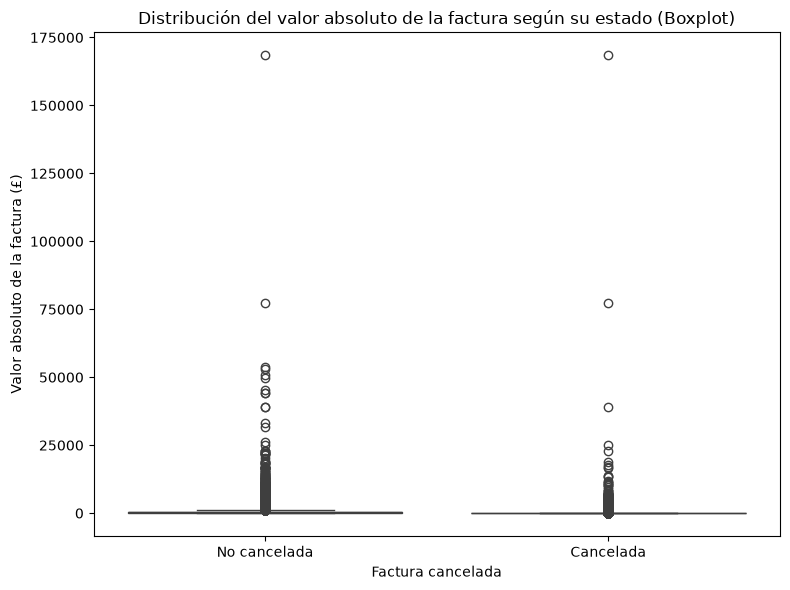

In [38]:
totales_facturas = (df.groupby(["invoice", "canceled"])["total_price"].sum().abs().reset_index())

plt.figure(figsize=(8, 6))

sns.boxplot(data=totales_facturas, x="canceled", y="total_price",
            hue="canceled", palette=["tab:blue", "tab:red"], legend=False)

plt.xticks([0, 1], ["No cancelada", "Cancelada"])
plt.xlabel("Factura cancelada")
plt.ylabel("Valor absoluto de la factura (£)")
plt.title("Distribución del valor absoluto de la factura según su estado (Boxplot)")

plt.tight_layout()
plt.show()


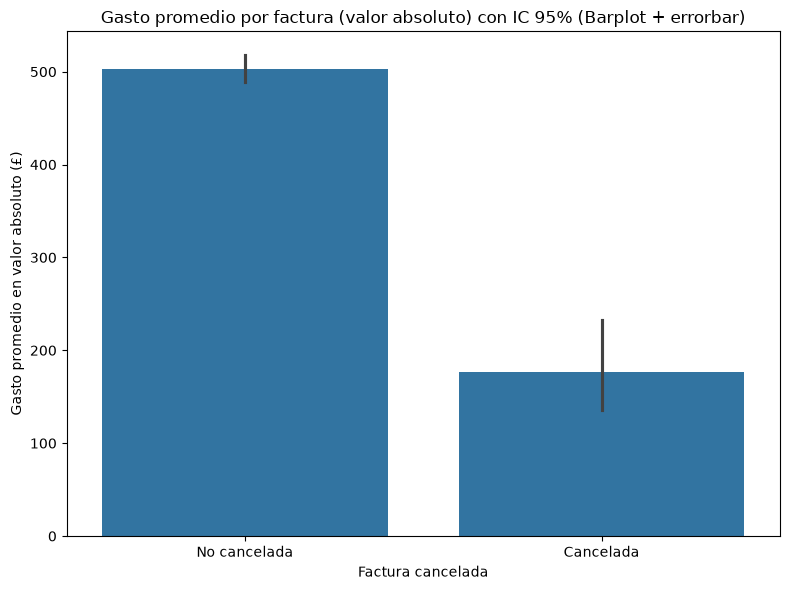

In [39]:
totales_facturas = (df.groupby(["invoice", "canceled"])["total_price"].sum().abs().reset_index())

plt.figure(figsize=(8, 6))

sns.barplot(data=totales_facturas, x="canceled", y="total_price", errorbar=("ci", 95))

plt.xticks([0, 1], ["No cancelada", "Cancelada"])
plt.xlabel("Factura cancelada")
plt.ylabel("Gasto promedio en valor absoluto (£)")
plt.title("Gasto promedio por factura (valor absoluto) con IC 95% (Barplot + errorbar)")

plt.tight_layout()
plt.show()


### Barplot con mediana + intervalo bootstrap (alternativa más robusta)

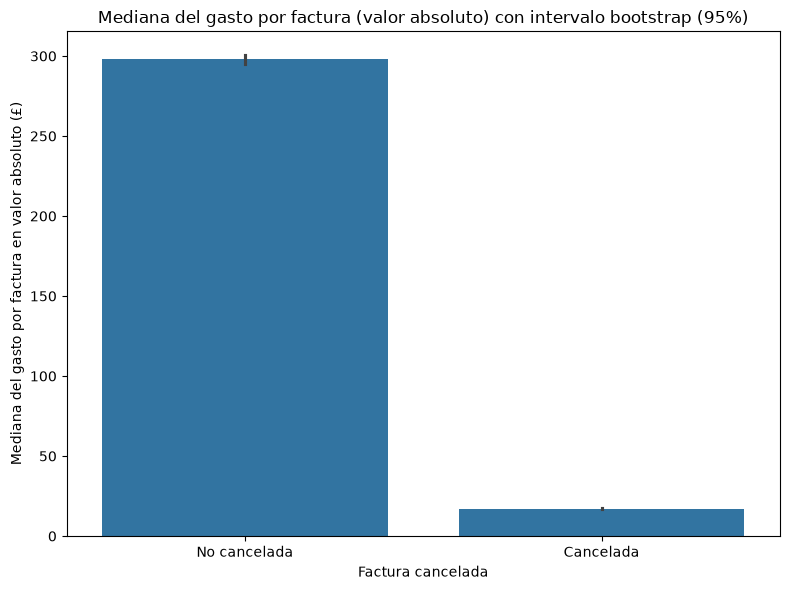

In [40]:
totales_facturas = (df.groupby(["invoice", "canceled"])["total_price"].sum().abs().reset_index())

plt.figure(figsize=(8, 6))

sns.barplot(data=totales_facturas, x="canceled", y="total_price",
            estimator=np.median, errorbar=("ci", 95), n_boot=1000, seed=42)

plt.xticks([0, 1], ["No cancelada", "Cancelada"])
plt.xlabel("Factura cancelada")
plt.ylabel("Mediana del gasto por factura en valor absoluto (£)")
plt.title("Mediana del gasto por factura (valor absoluto) con intervalo bootstrap (95%)")

plt.tight_layout()
plt.show()


### Prueba estadística: Mann–Whitney U

In [41]:
totales_facturas = (df.groupby(["invoice", "canceled"])["total_price"].sum().abs().reset_index())

no_canceladas = totales_facturas.loc[~totales_facturas["canceled"], "total_price"]
canceladas = totales_facturas.loc[totales_facturas["canceled"], "total_price"]

stat, p_value = mannwhitneyu(no_canceladas, canceladas, alternative="two-sided")

print(f"Estadístico U: {stat:.2f}")
print(f"Valor p: {p_value:.4f}")

if p_value < 0.05:
    print("Se rechaza H₀: existe una diferencia estadísticamente significativa entre el valor absoluto de facturas canceladas y no canceladas.")
else:
    print("No se rechaza H₀: no hay evidencia suficiente de una diferencia estadísticamente significativa.")


Estadístico U: 295933459.00
Valor p: 0.0000
Se rechaza H₀: existe una diferencia estadísticamente significativa entre el valor absoluto de facturas canceladas y no canceladas.


# 5. Hallazgos Claves

1. **Los regalos económicos para niños dominan las ventas.** Los 3 artículos más vendidos (aviones de cartón de la Segunda Guerra Mundial, porta velas colgantes con forma de corazón y un pack de manualidades de papel) son productos baratos, lo que confirma el perfil de "regalería" del negocio.

2. **El artículo más caro comprado fue una bandera de coche de Inglaterra**, vendida por casi £1.200, un precio llamativo para un producto de ese tipo, mientras que el resto del top 10 se compone principalmente de muebles.

3. **La relación entre precio unitario y cantidad comprada es prácticamente nula** (correlación de -0.029). El precio por sí solo no explica el volumen de compra en este negocio.

4. **El gasto promedio por factura es de £497,16, pero la mediana es de solo £301,23.** Esta gran diferencia confirma que existen clientes mayoristas que elevan fuertemente el promedio, mientras que la mayoría de las facturas (perfil minorista) se concentra en valores más bajos.

5. **Existe una factura extrema que distorsiona varios análisis**: la N° 581.483, por más de £160.000, correspondiente a la compra de casi 81.000 unidades de un solo artículo (paquetes de armado de papel de Little Birdie), explicando además por qué ese producto aparece en el top 3 de más vendidos.

6. **El cliente con la factura más cara del dataset también es uno de los que más gastó en total** (top 8 del ranking de clientes), lo que indica que se trata de un comprador mayorista recurrente y no de una compra aislada.

7. **La cantidad de compras cayó un 7,15% de 2010 a 2011**, contradiciendo la expectativa de que las compras online crecerían con el tiempo en este período.

8. **Noviembre es, por lejos, el mes con más compras**, coherente con las compras previas a Navidad y Año Nuevo; marzo aparece como un segundo pico, asociado a la Pascua de esos años.

9. **Las facturas se concentran entre las 6 y las 20 horas, con pico al mediodía**, un patrón que refleja que las facturas eran cargadas manualmente por empleados durante su horario laboral, y no el horario real de decisión de compra de los clientes.

10. **El negocio depende fuertemente del Reino Unido**: los clientes extranjeros (todos europeos) representan apenas un 9% de las ventas totales, algo esperable para una tienda sin comercio internacional consolidado en 2009-2011.


# 6. Conclusiones
Este proyecto me permitió recorrer el proceso completo de un análisis de datos real, desde la carga de un dataset con más de un millón de filas hasta la comunicación de hallazgos concretos. Trabajar con un dataset con datos faltantes, duplicados, códigos no comerciales y valores inconsistentes en cantidad y precio me obligó a tomar decisiones de limpieza justificadas en cada paso, en lugar de aplicar reglas automáticas, y creo que el resultado es un análisis que refleja bastante bien la realidad de una tienda de regalería online con una fuerte componente mayorista. En general, quedé conforme con el proyecto: pude combinar limpieza y formateo de datos, EDA con preguntas de negocio concretas, visualizaciones variadas y, en la última sección, un contraste estadístico formal en lugar de quedarme solo con la lectura visual de un gráfico.

Al mismo tiempo, noté algunas faltas en el dataset que limitan qué tan profundo puede llegar a ser el análisis. No hay ninguna variable que indique el motivo de una cancelación o devolución, lo que impide distinguir, por ejemplo, un error de carga de una insatisfacción real del cliente. Tampoco existen datos demográficos ni de segmentación de clientes (más allá del país), así que no se puede saber si el comportamiento de compra cambia según el tipo de cliente más allá de la distinción entre minorista y mayorista que se infiere indirectamente por el monto de la factura. Además, el dataset abarca poco más de dos años completos, lo cual es insuficiente para analizar tendencias de largo plazo o estacionalidad de manera robusta, y no incluye información de costos, por lo que no se puede calcular margen ni rentabilidad, solo facturación.

De cara a los próximos pasos, me gustaría profundizar el análisis de clientes mediante una segmentación tipo RFM (recencia, frecuencia, monto) para identificar distintos perfiles de compradores y detectar clientes en riesgo de abandono. También quiero explorar un análisis de canasta de mercado (market basket analysis) para ver qué productos se compran juntos, y armar un modelo simple de series de tiempo para las ventas mensuales que permita proyectar la demanda de los próximos meses. Por último, me interesa incorporar herramientas de visualización interactiva (como Dashboards en Power BI o Tableau) para que este análisis pueda navegarse dinámicamente en lugar de quedar fijo en un notebook.